In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "Dolson30"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
   # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Comparative Experiments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Comparative Experiments


# STAT 7220 - Midterm Exam
## David Olson

**DUE: October 28, 2025**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Counter-Strike) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

 - The Objective of this experiment is to determine if there is a statistically significant difference in the percieved comfort level of video game controller grips based on the material type used for the grip.

**Question 2.** Specify the outcome variable

 - The outcome variable (dependent variable) is the percieved comfort level rating given by the professional gamers. It is a quantitative variable with a 1 to 10 rating possible.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

- The independent variable is the material type used for the controller grips. Plastic, rubber, silicone, and metal being the options. (Side note, I sure hope metal "loses"... who would play CS with a metal grip!?).

- Some lurking variables include
    - Hand size and shape of the gamers, this could affect the feel of one material vs others.
    - Playing style or grip style. Some gamers hold controllers more tightly than others, and some gamers hold controllers differently than others.
    - Sweatiness. Despite the cliche, not all gamers sweat the same. Sweatier hands may impact the feel of smoother materials (metal or smooth plastic) more than the more textured materials.
    - Ambient Temperature in each gamers testing rooms. This falls under the above category, but the environment could impact the feel of some materials in cold/hot rooms, even outside of sweatiness.
    - Total hours played? Each gamer is given a month to use their controller, but it's possible that these gamers play a vastly different amount of the game in a given month. One could play for an hour a day, another for 8. This could impact wear and tear or general time spent getting comfortable with the controller.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

- CRD is appropriate because one single factor is being studied. Being focused solely on one independent variable, the material type, allows for a very simple and fundimental experimental design.

- Randomness of assignment is assumed here. The assumption is that the 40 total trials are independent and that differences between the 40 gamers are balanced across the four material groups due to randomization.

- Homogeneity of Experimental Units. This design assumes that the users are all professional gamers, they all play the same game, and they all use the controllers for the same duration. This would help us "ensure" that observed differences are due to the material type and not other pre-existing differences between the groups.

**Question 5.** State the null and alternative hypotheses for this experiment.

- Null Hypothesis: There is no statistically significant difference in the mean perceived comfort level among the four material types (plastic, rubber, silicone, and metal).

- Alternative Hypothesis: At least one of the mean perceived comfort levels is statistically different from the others.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

--- Summary Statistics by Material ---
          count  mean       std  min  max
Material                                 
Silicone     10  8.32  0.689283  7.3  9.2
Rubber       10  6.57  0.860297  5.3  8.0
Plastic      10  5.89  0.448330  5.2  6.8
Metal        10  4.95  0.538000  4.2  5.6


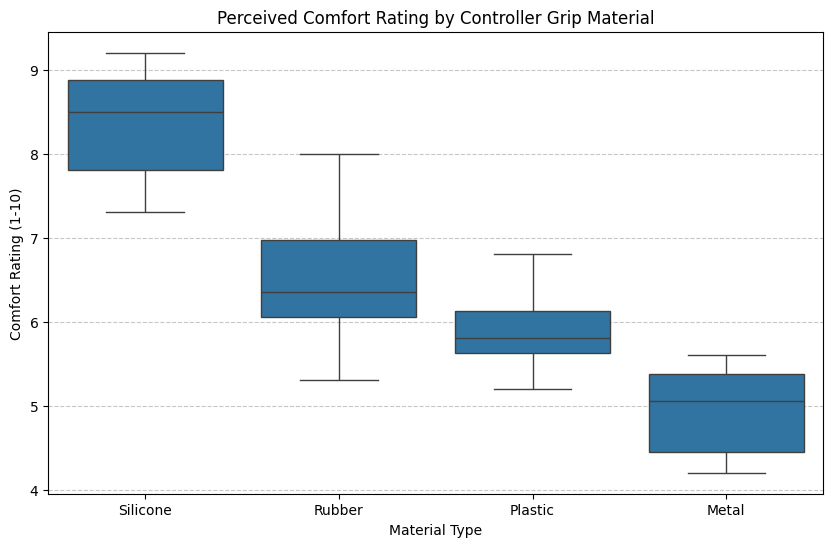

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam/Video Game Controllers.xlsx")

summary_stats = df.groupby('Material')['Comfort'].agg(['count', 'mean', 'std', 'min', 'max']).sort_values(by='mean', ascending=False)

print("--- Summary Statistics by Material ---")
print(summary_stats)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Material', y='Comfort', data=df, order=summary_stats.index)
plt.title('Perceived Comfort Rating by Controller Grip Material')
plt.xlabel('Material Type')
plt.ylabel('Comfort Rating (1-10)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- There are large differences between the sample means and there is not much overlap in the box plot, so that would suggest that the material type has a substantial impact on comfort while gaming.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?


Test Statistic (W): 0.9885
P-value: 0.9509


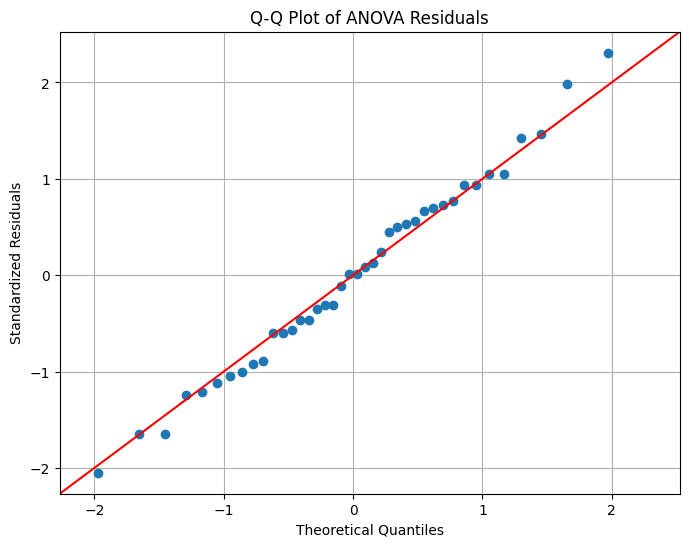

In [17]:
model = ols('Comfort ~ C(Material)', data=df).fit()
residuals = model.resid
shapiro_test = shapiro(residuals)
print(f"Test Statistic (W): {shapiro_test.statistic:.4f}")
print(f"P-value: {shapiro_test.pvalue:.4f}")

plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of ANOVA Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.grid(True)

- The results of both the Shapiro-Wilk test (high P-values) and the Q-Q plot ( a nice linear pattern) support the assumption of normality. This allows us to proceed with next steps in testing.

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?

Test Statistic (F): 2.0100
P-value: 0.1299


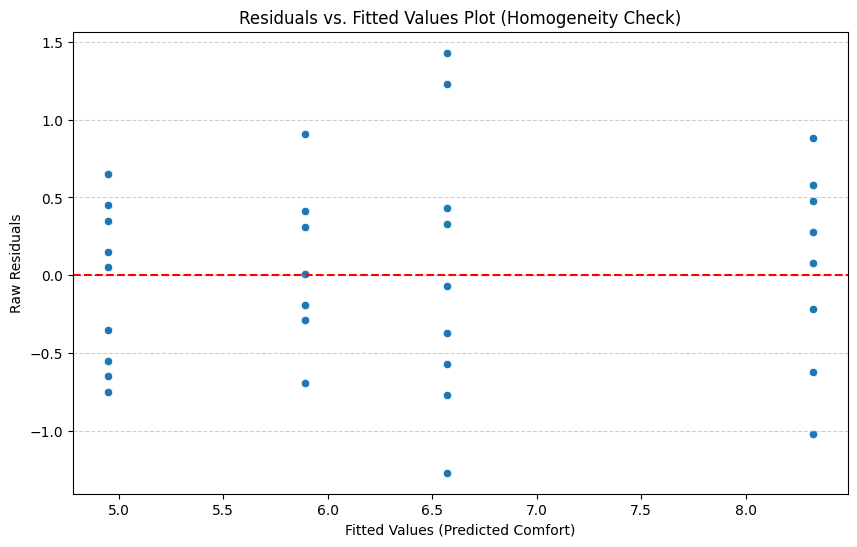

In [19]:
import pandas as pd
from statsmodels.formula.api import ols
from scipy.stats import levene
import matplotlib.pyplot as plt
import seaborn as sns

model = ols('Comfort ~ C(Material)', data=df).fit()

plastic = df[df['Material'] == 'Plastic']['Comfort']
rubber = df[df['Material'] == 'Rubber']['Comfort']
silicone = df[df['Material'] == 'Silicone']['Comfort']
metal = df[df['Material'] == 'Metal']['Comfort']

levene_test = levene(plastic, rubber, silicone, metal, center='mean')

print(f"Test Statistic (F): {levene_test.statistic:.4f}")
print(f"P-value: {levene_test.pvalue:.4f}")

fitted_values = model.fittedvalues
raw_residuals = model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=raw_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values Plot (Homogeneity Check)')
plt.xlabel('Fitted Values (Predicted Comfort)')
plt.ylabel('Raw Residuals')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

- A p-value of 0.1299 in Levene's test tells us that we fail to reject the null hypothesis (this is good in this case!) and that there are no statistically significant pieces of evidence to suggest that the variances in scores differ across material types. The fitted values polot shows us a relatively uniform scattering around zero.

- Both of these results support the assumption of homogeneity of variance.

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

In [20]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Comfort ~ C(Material)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
f_statistic = anova_table.loc['C(Material)', 'F']
p_value = anova_table.loc['C(Material)', 'PR(>F)']
print(f"\nF-statistic for Material: {f_statistic:.4f}")
print(f"P-value for Material: {p_value:.4f}")

               sum_sq    df          F        PR(>F)
C(Material)  60.73675   3.0  47.478405  1.348029e-12
Residual     15.35100  36.0        NaN           NaN

F-statistic for Material: 47.4784
P-value for Material: 0.0000


- Since the p-value of 0.0000 is much less than our typical significance level of 0.05, we reject the null hypothesis. This means there is sufficient evidence to conclude that at least one of the true mean comfort levels is significantly different from the others.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

In [21]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_results = pairwise_tukeyhsd(endog=df['Comfort'], groups=df['Material'], alpha=0.05)
print(tukey_results)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.94 0.0139  0.1535 1.7265   True
  Metal   Rubber     1.62    0.0  0.8335 2.4065   True
  Metal Silicone     3.37    0.0  2.5835 4.1565   True
Plastic   Rubber     0.68 0.1104 -0.1065 1.4665  False
Plastic Silicone     2.43    0.0  1.6435 3.2165   True
 Rubber Silicone     1.75    0.0  0.9635 2.5365   True
------------------------------------------------------


- This tells us that silicone is significantly more comfortable than all other materials. Rubber and plastic are not  that different from one another in terms of comfort. Metal is significantly less comfortable than all other materials (I KNEW IT!!).

- The results would suggest Silicone > Rubber / Plastic > Metal

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses.

**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Question 2.** Specify the outcome variable

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment.

**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

**Question 2.** What is the purpose of post-hoc tests?

**Question 3.** Explain the difference between RBD and LSD.

**Question 4.** Explain why randomization is important in designing experiments.

**Question 5.** Explain why replication is important in designing experiments.